# Reweighting a STARLING ensemble to a single experimental **Rg** with standard `BME`

The companion notebook (`bmecustom_saxs_reweighting.ipynb`) reweighted this ensemble against
the **full raw SAXS curve** using `BMECustom`. Here we do the more traditional thing: collapse
the scattering data to a single derived number — the **radius of gyration** — and reweight to
*that* using standard **`soursop.ssbme.BME`**.

The same `pnt.dat` SAXS data yield an Rg in (at least) two common ways, both provided here:

| source | file | Rg |
|--------|------|----|
| Guinier analysis | `guiner_analysis/pnt_guinier.txt` | 49.85 ± 0.37 Å |
| Molecular-form-factor (MFF) fit | `mff_analysis/pnt_MFF_fit.txt` | 51.11 ± 0.13 Å |

**How standard BME differs from `BMECustom`.** `BME` reweights against experimental
*observables* — each is a scalar with a value and an uncertainty (an `ExperimentalObservable`),
matched against a per-frame *calculated* value. Here the observable is Rg and the per-frame
calculation is each conformer's geometric Rg (straight from SOURSOP). It then has the
closed-form maximum-entropy solution that `BME` exploits.

**The question.** Does it matter whether we feed the reweighter the *raw scattering* or a
*single derived Rg*? We will reweight to the Guinier Rg, to the MFF Rg, and (for reference)
to the full curve, then compare what each does to the ensemble and to the agreement with the
actual scattering.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import glob
import re

import numpy as np
import matplotlib.pyplot as plt

from soursop.ssbme import BME, BMECustom, ExperimentalObservable
from soursop.sstrajectory import SSTrajectory

DATA_DIR = Path(".")
SAXS_FRAME_DIR = DATA_DIR / "saxs_frames"

## 1. Load the ensemble and compute per-frame Rg

The per-frame Rg is the *calculated* observable BME compares against experiment. SOURSOP
returns it directly; with no `weights` argument it is the per-conformer array.

In [2]:
traj = SSTrajectory(str(DATA_DIR / "pnt_STARLING.xtc"), str(DATA_DIR / "pnt_STARLING.pdb"))
protein = traj.proteinTrajectoryList[0]

rg = protein.get_radius_of_gyration()       # per-frame geometric Rg, shape (n_frames,)
n_frames = rg.size
calc_rg = rg.reshape(-1, 1)                  # BME wants (n_frames, n_observables)

print(f"{n_frames} conformers")
print(f"per-frame Rg: min={rg.min():.1f}  max={rg.max():.1f}  mean={rg.mean():.1f} A")

600 conformers
per-frame Rg: min=30.0  max=106.4  mean=57.1 A


## 2. Read the experimental Rg values

We parse the Rg (and its uncertainty) straight out of the two analysis reports. Note that the
two methods, applied to the *same* scattering data, do not agree exactly — the "experimental
Rg" is itself somewhat method-dependent.

In [3]:
def parse_rg(path):
    """Pull the first 'Rg = <value> +/- <unc>' pair out of an analysis report."""
    text = Path(path).read_text(encoding="utf-8")
    m = re.search(r"Rg\s*=\s*([0-9.]+)\D+([0-9.]+)", text)
    return float(m.group(1)), float(m.group(2))


rg_guinier, sig_guinier = parse_rg(DATA_DIR / "guiner_analysis" / "pnt_guinier.txt")
rg_mff, sig_mff = parse_rg(DATA_DIR / "mff_analysis" / "pnt_MFF_fit.txt")

print(f"Guinier Rg = {rg_guinier:.2f} +/- {sig_guinier:.2f} A")
print(f"MFF     Rg = {rg_mff:.2f} +/- {sig_mff:.2f} A")
print(f"prior ensemble <Rg> = {rg.mean():.2f} A  (the model is more expanded than the data)")

Guinier Rg = 49.85 +/- 0.37 A
MFF     Rg = 51.11 +/- 0.13 A
prior ensemble <Rg> = 57.10 A  (the model is more expanded than the data)


## 3. Reweight to a single Rg with `BME`

Each reweighting is three lines: wrap the target in an `ExperimentalObservable`, build a `BME`
with the per-frame Rg, and `fit`. With `auto_theta=True` (the default) BME runs an L-curve scan
internally and picks the penalty `theta` for us.

In [4]:
def reweight_to_rg(value, uncertainty, name):
    obs = [ExperimentalObservable(value=value, uncertainty=uncertainty, name=name)]
    bme = BME(obs, calc_rg)
    res = bme.fit(auto_theta=True, verbose=False)
    print(f"{name}:")
    print(f"    target Rg            = {value:.2f} A")
    print(f"    <Rg>  prior -> post  = {rg.mean():.2f} -> {res.weights @ rg:.2f} A")
    print(f"    chi^2 prior -> post  = {res.chi_squared_initial:.2f} -> {res.chi_squared_final:.3f}")
    print(f"    theta (auto)         = {res.theta:.3g}")
    print(f"    phi (eff. fraction)  = {res.phi:.3f}  -> ~{res.phi * n_frames:.0f}/{n_frames} frames")
    return res


res_guinier = reweight_to_rg(rg_guinier, sig_guinier, "Guinier Rg")
print()
res_mff = reweight_to_rg(rg_mff, sig_mff, "MFF Rg")

Guinier Rg:
    target Rg            = 49.85 A
    <Rg>  prior -> post  = 57.10 -> 49.91 A
    chi^2 prior -> post  = 377.10 -> 0.020
    theta (auto)         = 6.11
    phi (eff. fraction)  = 0.814  -> ~488/600 frames

MFF Rg:
    target Rg            = 51.11 A
    <Rg>  prior -> post  = 57.10 -> 51.11 A
    chi^2 prior -> post  = 2159.50 -> 0.002
    theta (auto)         = 6.11
    phi (eff. fraction)  = 0.870  -> ~522/600 frames


## 4. What does matching one Rg do to the ensemble?

Both reweightings pull the mean Rg onto their target. The weighted Rg distributions show how:
the ensemble is shifted toward (but not collapsed onto) its more compact members.

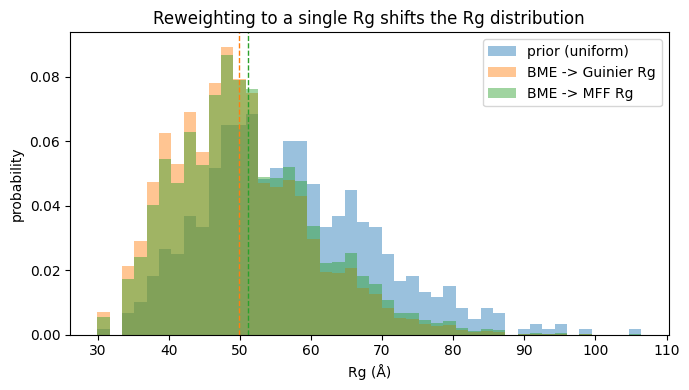

In [5]:
uniform = np.full(n_frames, 1.0 / n_frames)
bins = np.linspace(rg.min(), rg.max(), 45)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(rg, bins=bins, weights=uniform, alpha=0.45, label="prior (uniform)")
ax.hist(rg, bins=bins, weights=res_guinier.weights, alpha=0.45, label="BME -> Guinier Rg")
ax.hist(rg, bins=bins, weights=res_mff.weights, alpha=0.45, label="BME -> MFF Rg")
ax.axvline(rg_guinier, color="C1", ls="--", lw=1)
ax.axvline(rg_mff, color="C2", ls="--", lw=1)
ax.set_xlabel("Rg (\u00c5)")
ax.set_ylabel("probability")
ax.set_title("Reweighting to a single Rg shifts the Rg distribution")
ax.legend()
fig.tight_layout()

## 5. Does matching the Rg also match the raw scattering?

This is the crux. We load the experimental curve and the per-frame computed curves (as in the
`BMECustom` notebook), define the same scale-marginalised reduced χ², and **also run the
full-curve `BMECustom` fit** so we have a like-for-like reference. Then we score every set of
weights on how well it reproduces the actual scattering.

In [6]:
# experimental curve
exp = np.loadtxt(DATA_DIR / "pnt.dat")
q_exp, I_exp_raw, sigma_exp_raw = exp[:, 0], exp[:, 1], exp[:, 2]

# per-frame computed curves -> (n_frames, m)
frame_files = sorted(glob.glob(str(SAXS_FRAME_DIR / "frame_*.dat")))
q_calc = np.loadtxt(frame_files[0])[:, 0]
calc_curves = np.array([np.loadtxt(f)[:, 1] for f in frame_files])

# common grid
mask = (q_calc >= q_exp.min()) & (q_calc <= q_exp.max())
q = q_calc[mask]
I_exp = np.interp(q, q_exp, I_exp_raw)
sigma_exp = np.interp(q, q_exp, sigma_exp_raw)
C = calc_curves[:, mask]


def optimal_scale(avg, experiment, sigma):
    return np.sum(avg * experiment / sigma**2) / np.sum(avg**2 / sigma**2)


def curve_chi2(weights):
    """Scale-marginalised reduced chi^2 of the weighted average against the raw curve."""
    avg = weights @ C
    alpha = optimal_scale(avg, I_exp, sigma_exp)
    return float(np.mean(((alpha * avg - I_exp) / sigma_exp) ** 2))


# full-curve reference fit (BMECustom), theta from the companion notebook's L-curve
res_curve = BMECustom(I_exp, C, cost_function=lambda e, c, w: curve_chi2(w)).fit(
    theta=2.85, verbose=False)
print(f"BMECustom (full curve): <Rg> = {res_curve.weights @ rg:.2f} A, phi = {res_curve.phi:.3f}")

BMECustom (full curve): <Rg> = 52.91 A, phi = 0.775


In [7]:
weightings = [
    ("prior (uniform)", uniform, 1.0),
    ("BME -> Guinier Rg", res_guinier.weights, res_guinier.phi),
    ("BME -> MFF Rg", res_mff.weights, res_mff.phi),
    ("BMECustom (full curve)", res_curve.weights, res_curve.phi),
]

print(f"{'weighting':<24}{'<Rg> (A)':>10}{'phi':>7}{'curve chi2':>13}")
print("-" * 54)
for name, w, phi in weightings:
    print(f"{name:<24}{w @ rg:>10.2f}{phi:>7.2f}{curve_chi2(w):>13.2f}")

weighting                 <Rg> (A)    phi   curve chi2
------------------------------------------------------
prior (uniform)              57.10   1.00         4.40
BME -> Guinier Rg            49.91   0.81         2.94
BME -> MFF Rg                51.11   0.87         3.05
BMECustom (full curve)       52.91   0.77         1.13


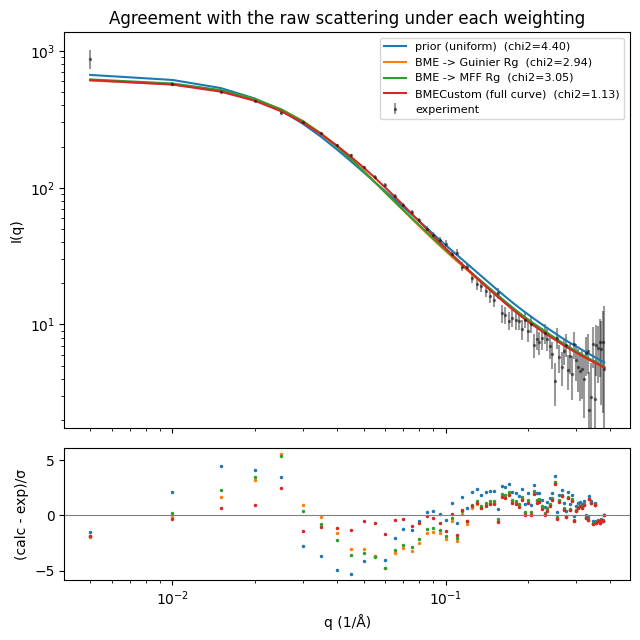

In [8]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(6.5, 6.5), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

ax1.errorbar(q, I_exp, yerr=sigma_exp, fmt="k.", ms=3, alpha=0.4, label="experiment")
for (name, w, _), color in zip(weightings, ["C0", "C1", "C2", "C3"]):
    avg = w @ C
    a = optimal_scale(avg, I_exp, sigma_exp)
    ax1.plot(q, a * avg, color=color, label=f"{name}  (chi2={curve_chi2(w):.2f})")
    ax2.plot(q, (a * avg - I_exp) / sigma_exp, ".", color=color, ms=3)

ax1.set_yscale("log")
ax1.set_ylabel("I(q)")
ax1.set_title("Agreement with the raw scattering under each weighting")
ax1.legend(fontsize=8)
ax2.axhline(0, color="gray", lw=0.8)
ax2.set_xscale("log")
ax2.set_xlabel("q (1/\u00c5)")
ax2.set_ylabel("(calc - exp)/\u03c3")
fig.tight_layout()

## 6. So — does using the raw scattering change the behaviour? Yes.

Reading the table and the fit plot together:

- **The derived Rg is method-dependent.** Guinier (49.85 Å) and MFF (51.11 Å) disagree by more
  than their stated uncertainties. `BME` faithfully reproduces *whichever* target you give it
  (`⟨Rg⟩` lands on 49.9 / 51.1 Å), so that choice propagates straight into your reweighted
  ensemble.
- **Matching one number only takes you part way.** Pulling in the mean Rg does improve the
  full-curve χ² (from ~4.4 toward ~3), because Rg is correlated with the low-q shape — but it
  leaves the curve clearly mis-fit relative to fitting it directly.
- **The raw curve carries shape information beyond Rg.** `BMECustom` on the full profile
  reaches a markedly better χ² (~1.1) and settles at `⟨Rg⟩ ≈ 52.9 Å` — *larger* than either
  Guinier or MFF. The complete q-range constrains the conformational distribution in a way a
  single moment cannot, and it points to an ensemble the single-Rg fits would have over-compacted.

**Practical guidance.** If you only have a derived Rg, `BME` against that Rg is the right tool
— just remember it (a) inherits the assumptions of whatever produced the Rg, and (b) constrains
only one moment of the size distribution. If you have the raw scattering, fitting it directly
(`BMECustom`) uses strictly more information and generally gives a better-constrained ensemble.

**Caveats.**
- *Geometric vs SAXS Rg.* SOURSOP's per-frame Rg is the geometric Rg of the modelled atoms;
  a SAXS Rg additionally reflects the hydration layer and solvent contrast. A small systematic
  offset between the two is expected, so treat the absolute match with appropriate caution.
- *Effective sample size.* Always check `phi` (and `result.print_diagnostics()`): tight Rg
  uncertainties force harder reweighting, and a fit that looks perfect with `phi -> 0` is
  over-fitting, not agreement.
- *Decoupled `theta`.* The three fits choose `theta` independently (BME auto-selects; the
  `BMECustom` reference reuses the companion notebook's value), so compare them by `phi` and the
  curve χ² rather than by the raw penalty.